# Preprocessing and Data Cleaning

### Imports / Pull in dataset

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Sleep = pd.read_csv('../data/sleep_health_dataset.csv')
Sleep.dtypes

person_id                        int64
age                              int64
gender                          object
occupation                      object
bmi                            float64
country                         object
sleep_duration_hrs             float64
sleep_quality_score            float64
rem_percentage                 float64
deep_sleep_percentage          float64
sleep_latency_mins               int64
wake_episodes_per_night          int64
caffeine_mg_before_bed           int64
alcohol_units_before_bed       float64
screen_time_before_bed_mins      int64
exercise_day                     int64
steps_that_day                   int64
nap_duration_mins                int64
stress_score                   float64
work_hours_that_day            float64
chronotype                      object
mental_health_condition         object
heart_rate_resting_bpm           int64
sleep_aid_used                   int64
shift_work                       int64
room_temperature_celsius 

### Feature Remapping

1. Drop person ID as it is not relevant to the data.
2. Because `sleep_disorder_risk` uses cateogircal values for ordered data, convert to numerical.
Note that we wait to include categorical variables for the sake of our correlation matrix.

In [106]:
Sleep = Sleep.drop(columns=['person_id'])

risk_map = {
    'Healthy': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}

Sleep['sleep_disorder_risk'] = Sleep['sleep_disorder_risk'].map(risk_map)

### Check for unhealthy correlations/data leakage

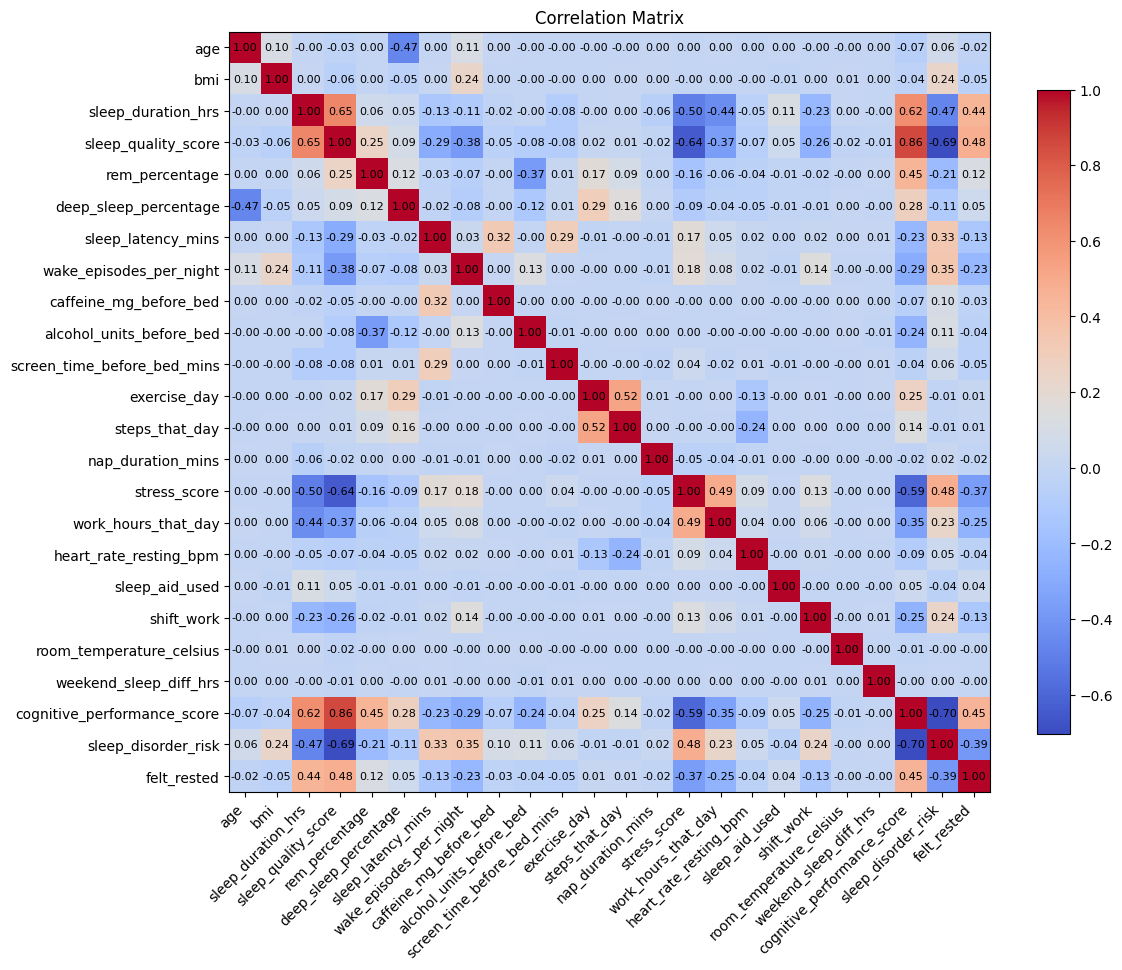

In [107]:
# create correlation matrix
numeric_df = Sleep.select_dtypes(include=['number'])
corr = numeric_df.corr()
columns = corr.columns

# init plot / colorbar / labels
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap='coolwarm')

fig.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(np.arange(len(columns)))
ax.set_yticks(np.arange(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha="right")
ax.set_yticklabels(columns)

# text values in each box
for i in range(len(columns)):
    for j in range(len(columns)):
        text = ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black", fontsize=8)

ax.set_title("Correlation Matrix")
fig.tight_layout()
plt.show()

### Remove data leakage

Sleep quality score and cognitive performance score (correlation score of 0.86) are forms of data leakage/multicollinearality. Specifically, sleep_quality_score is subjective data collected from the patients. It is probably best if we do not allow the model to learn that "if someone said they slept good, they likely felt rested". Cognitive performance score is a result of calculated aggregate from other features, and is best left out to make the model less "shallow".

In [108]:
cols_to_drop = [
    'sleep_quality_score',
    'cognitive_performance_score'
]
Sleep = Sleep.drop(columns=cols_to_drop)

### Now that we have the information we wanted from the correlation matrix, we will use one-hot encoding to get our categorical variables included into the model

In [109]:
Sleep = pd.get_dummies(Sleep, columns=['gender', 
                                       'occupation', 
                                       'country', 
                                       'chronotype', 
                                       'mental_health_condition', 
                                       'season', 
                                       'day_type'], 
                       dtype=int)

### Finally, we can train the model

In [110]:
X = Sleep.drop(columns=['felt_rested'])
y = Sleep['felt_rested']

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# we do not scale y because "felt_rested" is binary, which is not compatible
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

### We can now take our cleaned data and put it in .csv format for the remaining tasks

In [111]:
X_train_final.to_csv('../data/X_train.csv', index=False)
X_test_final.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)
print("Data has been successfully sent to the 'data/' directory.")

Data has been successfully sent to the 'data/' directory.
